## Vegetation Pattern Gallery

Visualises the different spatial vegetation patterns generated by `write_SWOF.py`.
Patterns are created in-memory (no simulation files written) by extracting the
core generation logic from each `write_veg_*` function.

### Pattern types

| Generator | Description | Key parameters |
|---|---|---|
| `blob` | Isotropic Gaussian-filtered blobs | `sigma`, `fV`, `seed` |
| `blob_aniso` | Anisotropic blobs (gradient- or contour-aligned) | `sigma`, `fV`, `aniso`, `seed` |
| `h_stripe` | Horizontal (cross-slope) stripes | `stripe_count`, `fV` |
| `v_stripe` | Vertical (along-slope) stripes | `stripe_count`, `fV` |
| `checkerboard` | Regular checkerboard patches | `nchecks`, `patch_scale` |
| `uniform` | Spatially uniform roughness | `fV` |

In [1]:
import warnings
warnings.filterwarnings('ignore')

import os, sys
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as _cm
import matplotlib.colors as _mcolors
from scipy.ndimage import gaussian_filter

sys.path.insert(0, '/Users/octaviacrompton/Projects/roughness-scale/swof_code')
sys.path.insert(0, '/Users/octaviacrompton/Projects/roughness-scale/src')

from labels import (
    FS_LABEL, FS_TITLE, FS_TICK, FS_LEG,
    VEG_COLORS, VEG_LABELS,
)

print('Ready')

Ready


In [2]:
# ── In-memory pattern generators ─────────────────────────────────────────────
# These reproduce the logic inside write_SWOF.py without writing files.

def make_veg_blob(Nx, Ny, sigma, fV, seed=1):
    """Isotropic Gaussian-filtered blobs."""
    rng = np.random.RandomState(seed)
    raw = rng.uniform(0, 1, (Nx, Ny))
    gauss = gaussian_filter(raw, sigma=sigma)
    threshold = np.percentile(gauss, fV * 100)
    veg = np.where(gauss <= threshold, 1.0, 0.0)
    return veg


def make_veg_blob_aniso(Nx, Ny, sigma, fV, aniso, seed=1):
    """Anisotropic blobs (aniso>0 → contour-aligned, aniso<0 → gradient-aligned)."""
    rng = np.random.RandomState(seed)
    raw = rng.uniform(0, 1, (Nx, Ny))
    r = abs(aniso) if aniso != 0 else 1
    if aniso > 0:
        sig = (sigma, sigma / r)      # contour-aligned: elongated cross-slope
    elif aniso < 0:
        sig = (sigma / r, sigma)      # gradient-aligned: elongated downslope
    else:
        sig = (sigma, sigma)           # isotropic
    gauss = gaussian_filter(raw, sigma=sig)
    threshold = np.percentile(gauss, fV * 100)
    veg = np.where(gauss <= threshold, 1.0, 0.0)
    return veg


def make_veg_h_stripe(Nx, Ny, stripe_count, fV, downslope='bare'):
    """Horizontal (cross-slope) stripes."""
    veg = np.zeros((Nx, Ny))
    veg_width = int(Ny * fV / stripe_count)
    bare_width = int(Ny * (1.0 - fV) / stripe_count)
    dist = Ny / stripe_count
    start = Ny - 1 - (bare_width if downslope == 'bare' else 0)
    for ind in range(veg_width):
        inds = np.arange(start - ind, 0, -dist, dtype=int)
        veg[:, inds] = 1
    return veg


def make_veg_v_stripe(Nx, Ny, stripe_count, fV, downslope='bare'):
    """Vertical (along-slope) stripes."""
    veg = np.zeros((Nx, Ny))
    veg_width = int(Nx * fV / stripe_count)
    bare_width = int(Nx * (1.0 - fV) / stripe_count)
    dist = Nx / stripe_count
    lower = 0 if downslope == 'bare' else bare_width
    for ind in range(veg_width):
        inds = np.arange(lower + ind, Nx, dist, dtype=int)
        veg[inds, :] = 1
    return veg


def make_veg_checkerboard(Nx, Ny, nchecks=8, patch_scale=0.5):
    """Regular checkerboard of vegetated patches."""
    ssize = int(Nx / nchecks)
    patch_length = int(ssize * patch_scale / 2)
    template = np.zeros((ssize, ssize))
    c = ssize // 2
    template[c - patch_length:c + patch_length + 1,
             c - patch_length:c + patch_length + 1] = 1
    tilex = Nx // ssize // 2
    tiley = Ny // ssize // 2
    tile = np.hstack((template, np.zeros_like(template)))
    tile = np.vstack((tile, np.fliplr(tile)))
    return np.tile(tile, (tilex, tiley))


def make_veg_uniform(Nx, Ny, fV=1.0):
    """Spatially uniform vegetation (all 1s or 0s)."""
    return np.ones((Nx, Ny)) if fV > 0 else np.zeros((Nx, Ny))


print(f'Pattern generators defined')

Pattern generators defined


### 1. Blob patterns — varying $\sigma$ and $f_V$

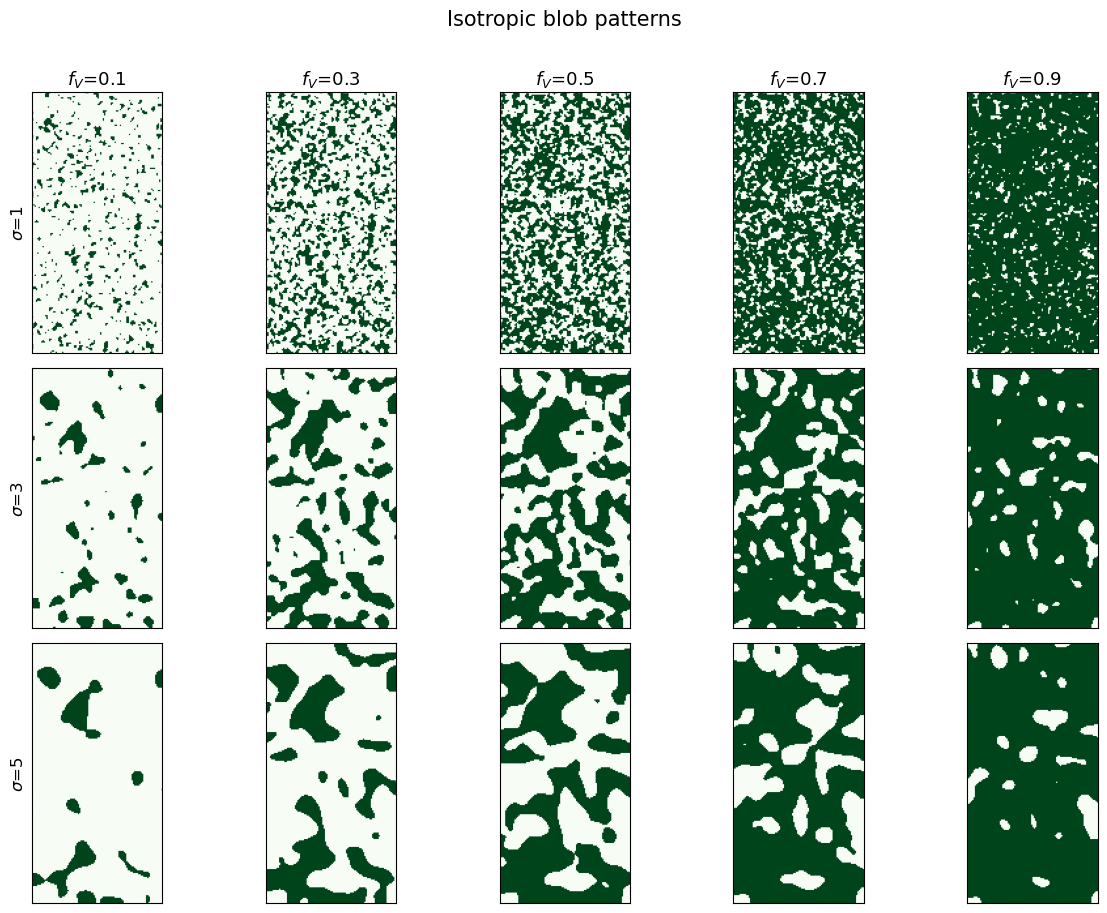

In [3]:
# Grid of blob patterns: rows = sigma, cols = fV
_Nx, _Ny = 100, 200
_sigmas = [1, 3, 5]
_fVs    = [0.1, 0.3, 0.5, 0.7, 0.9]

fig, axes = plt.subplots(len(_sigmas), len(_fVs),
                         figsize=(2.5 * len(_fVs), 3 * len(_sigmas)))

for ri, sigma in enumerate(_sigmas):
    for ci, fv in enumerate(_fVs):
        ax = axes[ri, ci]
        veg = make_veg_blob(_Nx, _Ny, sigma=sigma, fV=fv, seed=1)
        ax.imshow(veg.T, cmap='Greens', origin='lower', aspect='equal')
        ax.set_xticks([]); ax.set_yticks([])
        if ri == 0:
            ax.set_title(f'$f_V$={fv}', fontsize=FS_TITLE)
        if ci == 0:
            ax.set_ylabel(f'$\\sigma$={sigma}', fontsize=FS_LABEL)

fig.suptitle('Isotropic blob patterns', fontsize=FS_TITLE + 2, y=1.01)
plt.tight_layout()
plt.show()

### 2. Anisotropic blobs — effect of orientation

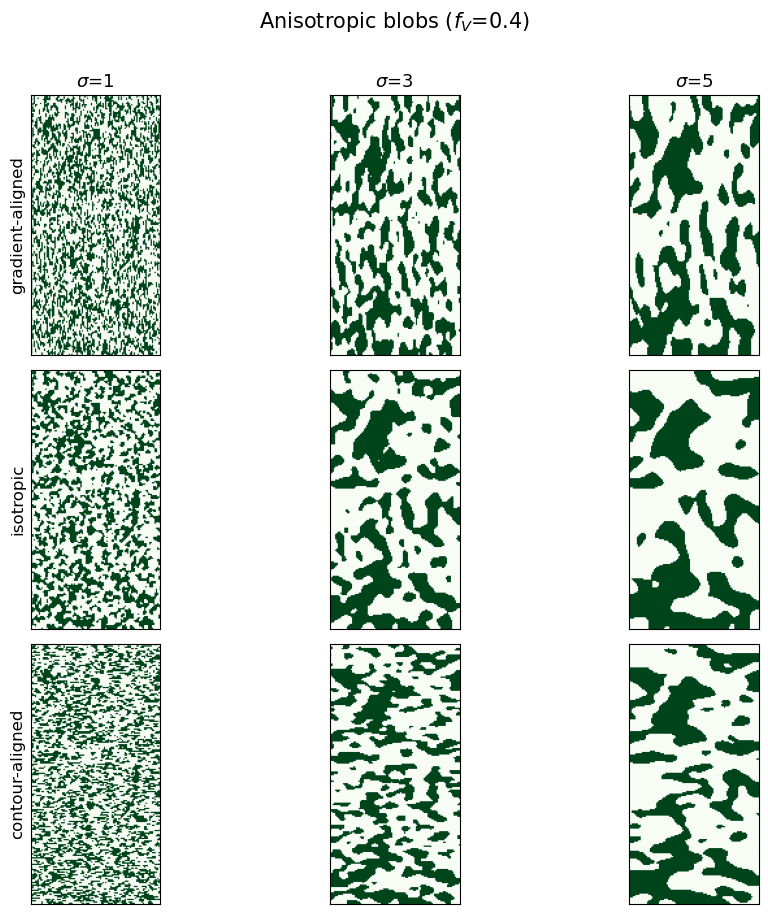

In [4]:
# Anisotropic blobs: rows = aniso value, cols = sigma
_Nx, _Ny = 100, 200
_anisos = [-2, 1, 2]
_sigmas = [1, 3, 5]
_fV = 0.4

_aniso_labels = {-2: 'gradient-aligned', 1: 'isotropic', 2: 'contour-aligned'}

fig, axes = plt.subplots(len(_anisos), len(_sigmas),
                         figsize=(3.5 * len(_sigmas), 3 * len(_anisos)))

for ri, aniso in enumerate(_anisos):
    for ci, sigma in enumerate(_sigmas):
        ax = axes[ri, ci]
        if aniso == 1:
            veg = make_veg_blob(_Nx, _Ny, sigma=sigma, fV=_fV, seed=1)
        else:
            veg = make_veg_blob_aniso(_Nx, _Ny, sigma=sigma, fV=_fV,
                                      aniso=aniso, seed=1)
        ax.imshow(veg.T, cmap='Greens', origin='lower', aspect='equal')
        ax.set_xticks([]); ax.set_yticks([])
        if ri == 0:
            ax.set_title(f'$\\sigma$={sigma}', fontsize=FS_TITLE)
        if ci == 0:
            ax.set_ylabel(_aniso_labels[aniso], fontsize=FS_LABEL)

fig.suptitle(f'Anisotropic blobs ($f_V$={_fV})', fontsize=FS_TITLE + 2, y=1.01)
plt.tight_layout()
plt.show()

### 3. Stripe patterns

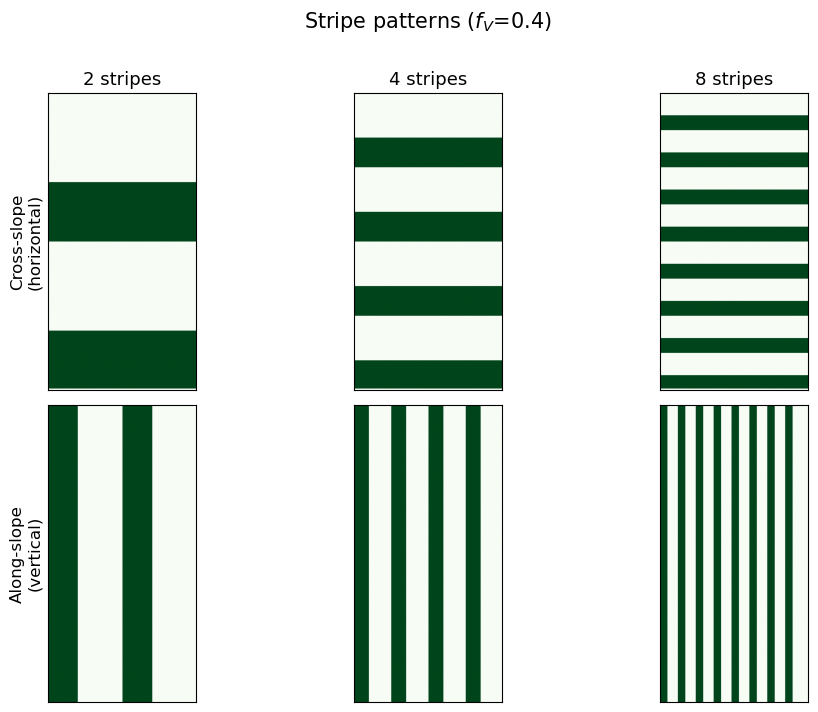

In [5]:
# Stripe patterns: horizontal vs vertical, varying stripe_count
_Nx, _Ny = 100, 200
_stripe_counts = [2, 4, 8]
_fV = 0.4

fig, axes = plt.subplots(2, len(_stripe_counts),
                         figsize=(3.5 * len(_stripe_counts), 7))

for ci, sc in enumerate(_stripe_counts):
    # cross-slope (horizontal)
    veg_h = make_veg_h_stripe(_Nx, _Ny, stripe_count=sc, fV=_fV)
    axes[0, ci].imshow(veg_h.T, cmap='Greens', origin='lower', aspect='equal')
    axes[0, ci].set_xticks([]); axes[0, ci].set_yticks([])
    axes[0, ci].set_title(f'{sc} stripes', fontsize=FS_TITLE)
    if ci == 0:
        axes[0, ci].set_ylabel('Cross-slope\n(horizontal)', fontsize=FS_LABEL)

    # along-slope (vertical)
    veg_v = make_veg_v_stripe(_Nx, _Ny, stripe_count=sc, fV=_fV)
    axes[1, ci].imshow(veg_v.T, cmap='Greens', origin='lower', aspect='equal')
    axes[1, ci].set_xticks([]); axes[1, ci].set_yticks([])
    if ci == 0:
        axes[1, ci].set_ylabel('Along-slope\n(vertical)', fontsize=FS_LABEL)

fig.suptitle(f'Stripe patterns ($f_V$={_fV})', fontsize=FS_TITLE + 2, y=1.01)
plt.tight_layout()
plt.show()

### 4. Checkerboard patterns

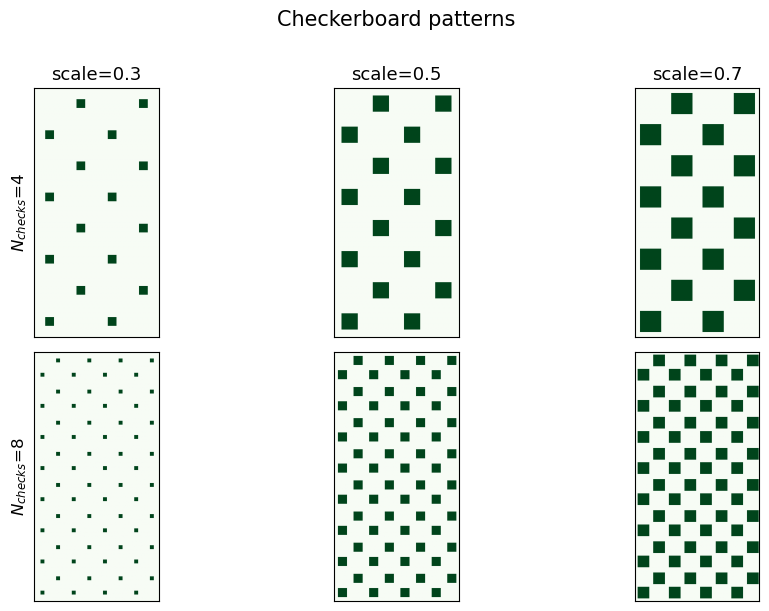

In [6]:
# Checkerboard: varying nchecks and patch_scale
_Nx, _Ny = 100, 200
_nchecks_list  = [4, 8]
_scales = [0.3, 0.5, 0.7]

fig, axes = plt.subplots(len(_nchecks_list), len(_scales),
                         figsize=(3.5 * len(_scales), 3 * len(_nchecks_list)))

for ri, nc in enumerate(_nchecks_list):
    for ci, ps in enumerate(_scales):
        ax = axes[ri, ci]
        veg = make_veg_checkerboard(_Nx, _Ny, nchecks=nc, patch_scale=ps)
        ax.imshow(veg[:_Nx, :_Ny].T, cmap='Greens', origin='lower', aspect='equal')
        ax.set_xticks([]); ax.set_yticks([])
        if ri == 0:
            ax.set_title(f'scale={ps}', fontsize=FS_TITLE)
        if ci == 0:
            ax.set_ylabel(f'$N_{{checks}}$={nc}', fontsize=FS_LABEL)

fig.suptitle('Checkerboard patterns', fontsize=FS_TITLE + 2, y=1.01)
plt.tight_layout()
plt.show()

### 5. Side-by-side comparison of all pattern types

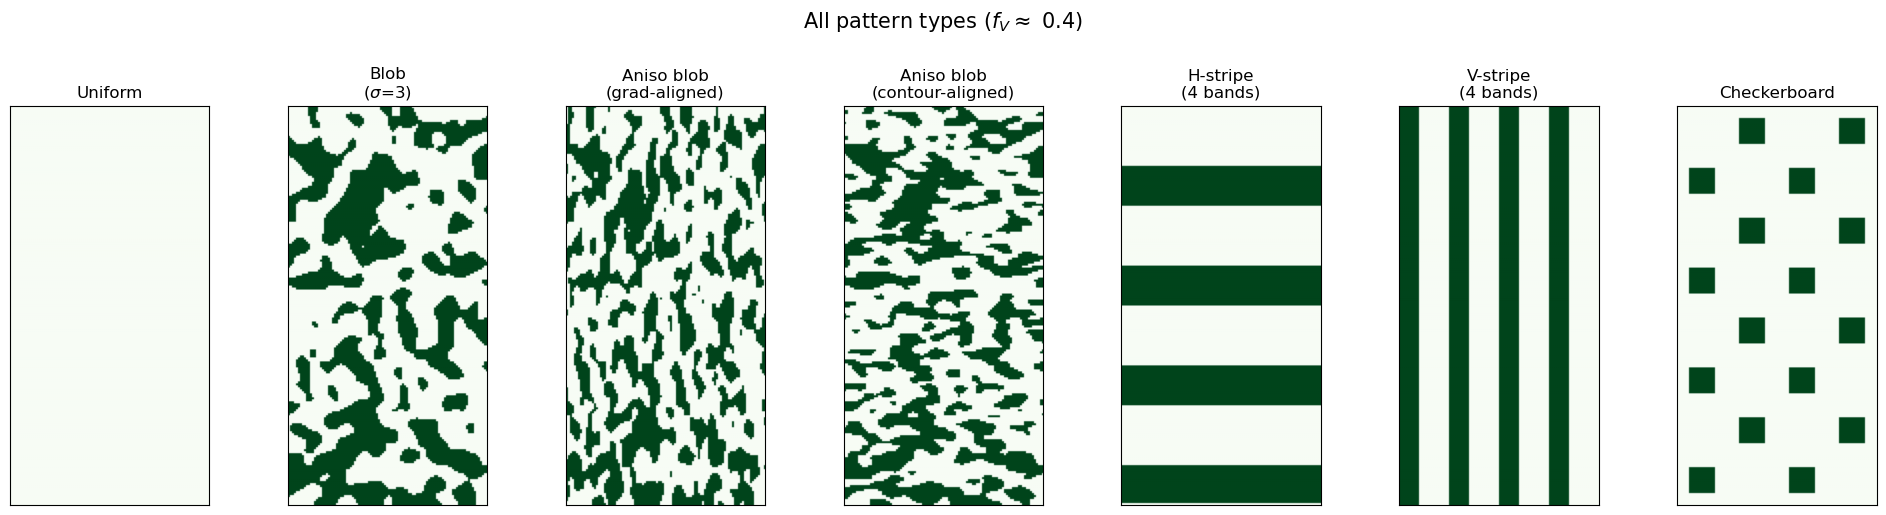

In [7]:
# Side-by-side: one example of each pattern type
_Nx, _Ny = 100, 200
_fV = 0.4

_patterns = [
    ('Uniform',          make_veg_uniform(_Nx, _Ny, fV=1.0)),
    ('Blob\n($\\sigma$=3)', make_veg_blob(_Nx, _Ny, sigma=3, fV=_fV, seed=1)),
    ('Aniso blob\n(grad-aligned)', make_veg_blob_aniso(_Nx, _Ny, sigma=3, fV=_fV, aniso=-2, seed=1)),
    ('Aniso blob\n(contour-aligned)', make_veg_blob_aniso(_Nx, _Ny, sigma=3, fV=_fV, aniso=2, seed=1)),
    ('H-stripe\n(4 bands)', make_veg_h_stripe(_Nx, _Ny, stripe_count=4, fV=_fV)),
    ('V-stripe\n(4 bands)', make_veg_v_stripe(_Nx, _Ny, stripe_count=4, fV=_fV)),
    ('Checkerboard',     make_veg_checkerboard(_Nx, _Ny, nchecks=4, patch_scale=0.5)),
]

fig, axes = plt.subplots(1, len(_patterns), figsize=(2.8 * len(_patterns), 5))
for i, (label, veg) in enumerate(_patterns):
    ax = axes[i]
    ax.imshow(veg[:_Nx, :_Ny].T, cmap='Greens', origin='lower', aspect='equal')
    ax.set_xticks([]); ax.set_yticks([])
    ax.set_title(label, fontsize=FS_TITLE - 1)

fig.suptitle(f'All pattern types ($f_V \\approx$ {_fV})', fontsize=FS_TITLE + 2, y=1.02)
plt.tight_layout()
plt.show()

### 6. Interactive explorer

In [ ]:
import ipywidgets as _widgets

def _interactive_pattern(pattern_type='blob', sigma=3, fV=0.4,
                         aniso=1, stripe_count=4, nchecks=8,
                         patch_scale=0.5, seed=1):
    Nx, Ny = 100, 200

    if pattern_type == 'blob':
        veg = make_veg_blob(Nx, Ny, sigma=sigma, fV=fV, seed=seed)
    elif pattern_type == 'blob_aniso':
        veg = make_veg_blob_aniso(Nx, Ny, sigma=sigma, fV=fV,
                                   aniso=aniso, seed=seed)
    elif pattern_type == 'h_stripe':
        veg = make_veg_h_stripe(Nx, Ny, stripe_count=stripe_count, fV=fV)
    elif pattern_type == 'v_stripe':
        veg = make_veg_v_stripe(Nx, Ny, stripe_count=stripe_count, fV=fV)
    elif pattern_type == 'checkerboard':
        veg = make_veg_checkerboard(Nx, Ny, nchecks=nchecks,
                                     patch_scale=patch_scale)
    else:
        veg = make_veg_uniform(Nx, Ny, fV=fV)

    fig, ax = plt.subplots(figsize=(5, 8))
    ax.imshow(veg[:Nx, :Ny].T, cmap='Greens', origin='lower', aspect='equal')
    ax.set_xticks([]); ax.set_yticks([])
    _actual_fv = veg[:Nx, :Ny].mean()
    ax.set_title(f'{pattern_type}  (actual $f_V$={_actual_fv:.2f})',
                 fontsize=FS_TITLE)
    plt.tight_layout()
    plt.show()

_widgets.interact(
    _interactive_pattern,
    pattern_type=_widgets.Dropdown(
        options=['uniform', 'blob', 'blob_aniso', 'h_stripe',
                 'v_stripe', 'checkerboard'],
        value='blob', description='Pattern:'),
    sigma=_widgets.IntSlider(min=1, max=10, step=1, value=3,
                             description='sigma:'),
    fV=_widgets.FloatSlider(min=0.05, max=0.95, step=0.05, value=0.4,
                            description='fV:'),
    aniso=_widgets.IntSlider(min=-5, max=5, step=2, value=1,
                             description='aniso:'),
    stripe_count=_widgets.IntSlider(min=1, max=10, step=1, value=4,
                                    description='stripes:'),
    nchecks=_widgets.Dropdown(options=[2, 4, 8, 10], value=4,
                              description='nchecks:'),
    patch_scale=_widgets.FloatSlider(min=0.1, max=0.9, step=0.1, value=0.5,
                                     description='patch scale:'),
    seed=_widgets.IntSlider(min=0, max=10, step=1, value=1,
                            description='seed:'),
)

interactive(children=(Dropdown(description='Pattern:', index=1, options=('uniform', 'blob', 'blob_aniso', 'h_s…

<function __main__._interactive_pattern(pattern_type='blob', sigma=3, fV=0.4, aniso=1, stripe_count=4, nchecks=8, patch_scale=0.5, seed=1)>

### 7. Notebook vs `write_SWOF.py` anisotropy comparison

`write_SWOF.py` was updated to use `abs(aniso)` (matching the notebook logic).
This cell confirms both implementations now produce identical output.

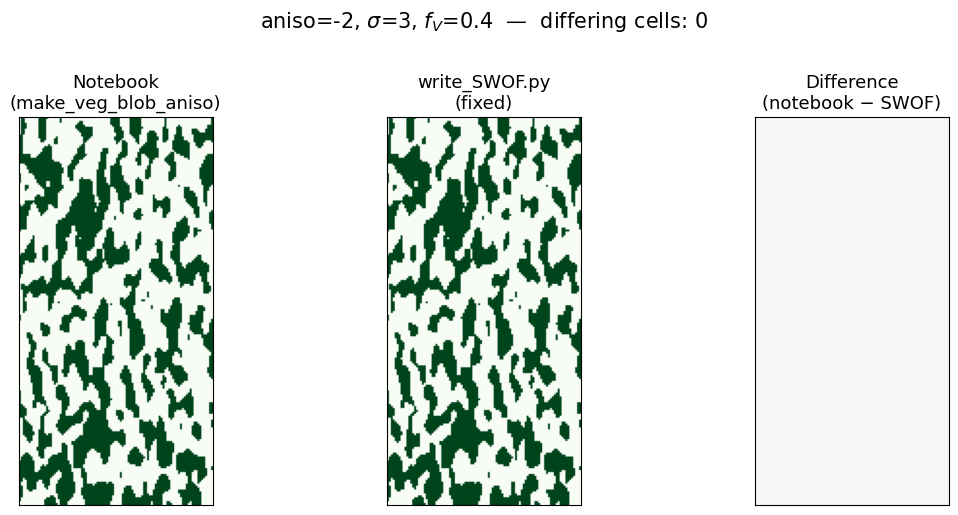

In [11]:
# Compare notebook make_veg_blob_aniso vs fixed write_SWOF.py logic
_Nx, _Ny = 100, 200
_sigma, _aniso, _fV, _seed = 3, -2, 0.4, 1

# ── Notebook version ─────────────────────────────────────────────────────────
_veg_notebook = make_veg_blob_aniso(_Nx, _Ny, sigma=_sigma, fV=_fV,
                                     aniso=_aniso, seed=_seed)

# ── Fixed write_SWOF.py version (uses abs, matches notebook) ────────────────
_rng = np.random.RandomState(_seed)
_raw = _rng.uniform(0, 1, (_Nx, _Ny))
_r = abs(_aniso) if _aniso != 0 else 1
if _aniso > 0:
    _sig_swof = (_sigma, _sigma / _r)       # contour-aligned
elif _aniso < 0:
    _sig_swof = (_sigma / _r, _sigma)       # gradient-aligned
else:
    _sig_swof = (_sigma, _sigma)             # isotropic
_gauss_swof = gaussian_filter(_raw, sigma=_sig_swof)
_thresh = np.percentile(_gauss_swof, _fV * 100)
_veg_swof = np.where(_gauss_swof <= _thresh, 1.0, 0.0)

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(12, 5))

axes[0].imshow(_veg_notebook.T, cmap='Greens', origin='lower', aspect='equal')
axes[0].set_title('Notebook\n(make_veg_blob_aniso)', fontsize=FS_TITLE)

axes[1].imshow(_veg_swof.T, cmap='Greens', origin='lower', aspect='equal')
axes[1].set_title('write_SWOF.py\n(fixed)', fontsize=FS_TITLE)

_diff = _veg_notebook - _veg_swof
axes[2].imshow(_diff.T, cmap='RdBu', origin='lower', aspect='equal',
               vmin=-1, vmax=1)
axes[2].set_title('Difference\n(notebook − SWOF)', fontsize=FS_TITLE)

for ax in axes:
    ax.set_xticks([]); ax.set_yticks([])

_n_diff = int(np.sum(_diff != 0))
fig.suptitle(f'aniso={_aniso}, $\\sigma$={_sigma}, $f_V$={_fV}  —  '
             f'differing cells: {_n_diff}',
             fontsize=FS_TITLE + 2, y=1.02)
plt.tight_layout()
plt.show()